# IMC-Denoise: a content aware denoising pipeline to enhance imaging mass cytometry

Here we will show an example for denoising the images with marker CD14 from our own human bone marrow IMC dataset. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IMC_Denoise.DeepSNiF_utils.DeepSNiF_DataGenerator import DeepSNiF_DataGenerator, load_training_patches
from IMC_Denoise.IMC_Denoise_main.DeepSNiF import DeepSNiF

In [6]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices()


Num GPUs Available:  1


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [7]:
import os
import glob



In [8]:
tf.__version__

'2.6.2'

### Training data preparation
Next, we use our raw images to build a training set.
Note: 
1. The channel name must be consistant with the corresponding channel name in the image file names. For example, in our dataset, CD14 is conjucted with 144Nd. If the images with marker CD14 need to be denoised, the channel name will be set as its isotope name "144Nd".
2. Raw_directory is the folder of all the raw images used for generating training set. Its subfolders are the imagesets of different tissues. The subfolders contains the images from all the channels of the same tissue. 
<b><br>Data_structure example:
<b><br>|---Raw_image_directory
<br>|---|---Tissue1
<br>|---|---|---Channel1_img.tiff
<br>|---|---|---Channel2_img.tiff
<br>             ...
<br>|---|---|---Channel_n_img.tiff
<br>|---|---Tissue2
<br>|---|---|---Channel1_img.tiff
<br>|---|---|---Channel2_img.tiff
<br>             ...
<br>|---|---|---Channel_n_img.tiff
<br>             ...
<br>|---|---Tissue_m
<br>|---|---|---Channel1_img.tiff
<br>|---|---|---Channel2_img.tiff
<br>             ...
<br>|---|---|---Channel_n_img.tiff
</b>
3. Save_directory is the folder used for saving generated training data. If None, it will be saved in the default folder. For CD14, the saved training set is "training_set_144Nd.npz".
4. n_neighbour and n_lambda are the parameters from DIMR algorithm for hot pixel removal in the training set generation process. 4 and 5 are their defaults. If the defaults are changed, the corresponding parameter should be declared in DeepSNiF_DataGenerator(). Otherwise, they can be omitted.
5. The DeepSNiF_DataGenerator class search all the CD14 images in raw image directory, split them into multiple 64x64 patches, and then augment the generated data. Note the very sparse patches are removed in this process.
6. Here we will save the generated training set and later reload it.

In [9]:
channel_name = "CD45"
Save_directory = None # If None, it will be saved in the default folder.

In [6]:
# Release memory
if 'generated_patches' in globals():
    del generated_patches
Raw_directory = "/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/" # change this directory to your Raw_image_directory.
    



n_neighbours = 4 # Larger n enables removing more consecutive hot pixels. 
n_iter = 3 # Iteration number for DIMR

DataGenerator = DeepSNiF_DataGenerator(channel_name = channel_name, n_neighbours = n_neighbours, n_iter = n_iter)
generated_patches = DataGenerator.generate_patches_from_directory(load_directory = Raw_directory)
if DataGenerator.save_patches(generated_patches, save_directory = Save_directory):
    print('Data generated successfully!')

Image data loaded from ...

/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap081_8/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap086_4/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap009_4/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap043_1/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap033_8/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap064_8/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap034_14/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap073_9/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap017_14/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap045_11/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap092_1/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap059_8/CD45.tiff
/home/giuseppe/devices/Delta_Tissue/IMC/split_channels/Leap018_13/CD4

KeyboardInterrupt: 

In [37]:
import glob
import os
path0 = "/home/giuseppe/devices/Delta_Tissue/IMC/split_channels_nohpf/"
#acquisition_ID = [*map(lambda x:x.lstrip(path0),glob.glob(path0+"*/", recursive = True))]
acquisition_dirs = [d for d in os.listdir(path0) if os.path.isdir(os.path.join(path0, d))]

if acquisition_dirs:
    # Take the first directory in the list
    first_acq_dir = os.path.join(path0, acquisition_dirs[0])
    
    # Get a list of acquisition IDs by removing the file extension from files in the first directory
    markers = [os.path.splitext(file)[0] for file in os.listdir(first_acq_dir) if file.endswith('.tiff')]
markers

['B7-H4',
 'Alpha-SMA',
 'CD107a',
 'CD8a',
 'CD14',
 'CD31',
 'Carboplatin',
 'PD-L2',
 'CD27',
 'CD44',
 'PD-L1',
 'E-Cadherin',
 'CD4',
 'CD366',
 'PD-1',
 'CD11b',
 'VEGF',
 'Pan-keratin',
 'EGFR',
 'CD45',
 'CD38',
 'CD68',
 'HLA-DR-DQ-DP',
 'DNA1',
 'Vimentin',
 'Granzyme-B',
 'FOXP3',
 'Beta-Catenin',
 'CD20',
 'CD45RO',
 'Tbet',
 'Collage-Type_I',
 'CD3',
 'Ki-67',
 'CD163',
 'CD16',
 'DNA2',
 'p53']

### Show several generated patches of the training set: Anscombe transformed.

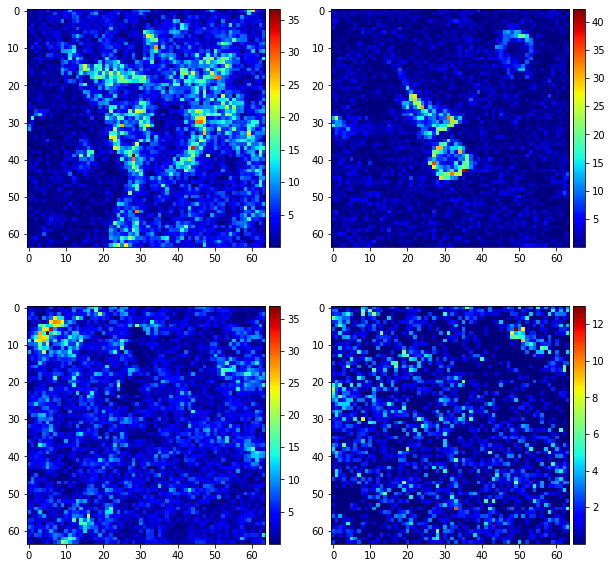

In [10]:
# show several generated patches of the training set, Anscombe transformed.
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig = plt.figure(figsize=(10, 10))

ax1 = fig.add_subplot(221)
im1 = ax1.imshow(generated_patches[0,:,:], cmap = 'jet')
divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im1, cax=cax, orientation='vertical')

ax2 = fig.add_subplot(222)
im2 = ax2.imshow(generated_patches[100,:,:], cmap = 'jet')
divider = make_axes_locatable(ax2)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im2, cax=cax, orientation='vertical')

ax3 = fig.add_subplot(223)
im3 = ax3.imshow(generated_patches[1000,:,:], cmap = 'jet')
divider = make_axes_locatable(ax3)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im3, cax=cax, orientation='vertical')

ax4 = fig.add_subplot(224)
im4 = ax4.imshow(generated_patches[-1,:,:], cmap = 'jet')
divider = make_axes_locatable(ax4)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im4, cax=cax, orientation='vertical')

### Load the generated training data from directory

In [10]:
saved_training_set = 'training_set_'+channel_name+'.npz'
train_data = load_training_patches(filename = saved_training_set, save_directory = Save_directory)
print('The shape of the loaded training set is ' + str(train_data.shape))

The shape of the loaded training set is (1248656, 64, 64)


### DeepSNiF configuration and training
Define parameters for DeepSNiF training. If is_load_weights is True, the pre-trained model and pre-calculated range of the marker channel will be loaded. The range value is used for normalization in prediction.

In [13]:
train_epoches = 50 # training epoches, which should be about 200 for a good training result. The default is 200.
train_initial_lr = 1e-3 # inital learning rate. The default is 1e-3.
train_batch_size = 128 # training batch size. For a GPU with smaller memory, it can be tuned smaller. The default is 128.
pixel_mask_percent = 0.2 # percentage of the masked pixels in each patch. The default is 0.2.
val_set_percent = 0.15 # percentage of validation set. The default is 0.15.
loss_function = "I_divergence" # loss function used. The default is "I_divergence".
weights_name = "weights_"+channel_name+".hdf5" # trained network weights name. If None, the weights will not be saved.
loss_name = None # training and validation losses name, either .mat or .npz format. If not defined, the losses will not be saved.
weights_save_directory = None # location where 'weights_name' and 'loss_name' saved.
# If the value is None, the files will be saved in a sub-directory named "trained_weights" of the current file folder.
is_load_weights = False # Use the trained model directly. Will not read from any saved ones.
lambda_HF = 3e-6 # HF regularization parameter.
deepsnif = DeepSNiF(train_epoches = train_epoches, 
                  train_learning_rate = train_initial_lr,
                  train_batch_size = train_batch_size,
                  mask_perc_pix = pixel_mask_percent,
                  val_perc = val_set_percent,
                  loss_func = loss_function,
                  weights_name = weights_name,
                  loss_name = loss_name,
                  weights_dir = weights_save_directory, 
                  is_load_weights = is_load_weights,
                  lambda_HF = lambda_HF,
                  network_size = 'small')

### Start training
If errors happen, check if the GPUs are being used by other sessions.

In [12]:
train_loss, val_loss = deepsnif.train(train_data)

/home/giuseppe/anaconda3/envs/IMC_Denoise/lib/python3.6/site-packages/keras/optimizer_v2/optimizer_v2.py:356: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


The range value to the corresponding model is 252.1163040161133.
Input Channel Shape => (1248656, 64, 64, 1)
Number of Training Examples: 1061357
Number of Validation Examples: 187299
Each training patch with shape of (64, 64) will mask 8 pixels.
Training model...
Epoch 1/50


/home/giuseppe/anaconda3/envs/IMC_Denoise/lib/python3.6/site-packages/keras/engine/training.py:1972: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


8292/8292 [==============================] - ETA: 0s - loss: 0.0064

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

### Plot the training and validation losses

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(np.array(range(len(train_loss))),train_loss, color='red', marker='^', linewidth=2, markersize=8)
plt.plot(np.array(range(len(val_loss))),val_loss, color='blue', marker='o', linestyle='dashed', linewidth=2, markersize=8)
plt.xlabel('Epoches')
plt.ylabel('BCE losses')
plt.legend(['training loss', 'val loss'])
plt.show()

NameError: name 'train_loss' is not defined

<Figure size 576x360 with 0 Axes>

In [ ]:
a